### **Amazon Alexa Sentiment Analysis (Random Forest)**

In [1]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules

# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
!kaggle datasets download -d sid321axn/amazon-alexa-reviews

Dataset URL: https://www.kaggle.com/datasets/sid321axn/amazon-alexa-reviews
License(s): other
100% 164k/164k [00:00<00:00, 17.7MB/s]



In [3]:
!unzip amazon-alexa-reviews.zip

Archive:  amazon-alexa-reviews.zip
  inflating: amazon_alexa.tsv        


In [4]:
import pandas as pd

df = pd.read_csv('amazon_alexa.tsv', sep='\t')
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


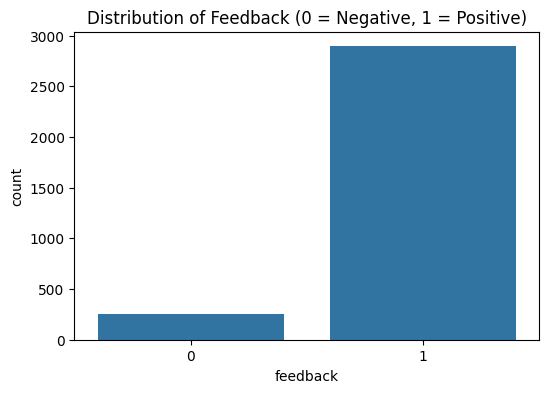

In [5]:
# Data Visualization and Clean Up
# TODO: Visualize the distribution of feedback
# Hint: Use seaborn's countplot function

# Data Visualization

# Distribution of feedback
plt.figure(figsize=(6,4))
sns.countplot(x='feedback', data=df)
plt.title("Distribution of Feedback (0 = Negative, 1 = Positive)")
plt.show()

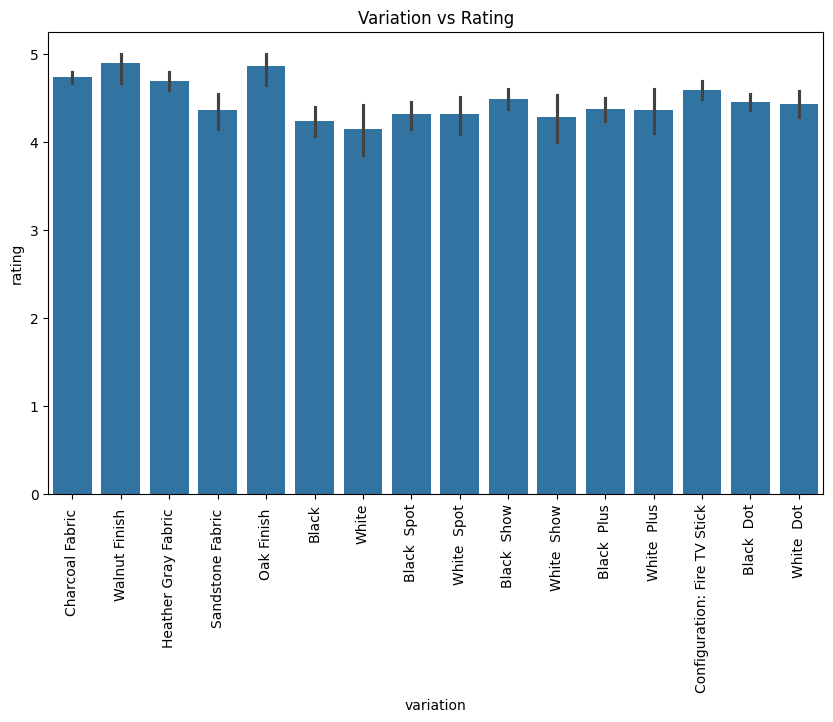

In [6]:
# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function

# Relationship between variations and ratings
plt.figure(figsize=(10,6))
sns.barplot(x='variation', y='rating', data=df)
plt.xticks(rotation=90)
plt.title("Variation vs Rating")
plt.show()

In [7]:
# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns

# Data Cleaning

# Drop irrelevant columns
df = df.drop(['date', 'rating'], axis=1)

In [8]:
# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function

# One-Hot Encoding (Variation)

variation_dummies = pd.get_dummies(df['variation'], drop_first=True)

In [9]:
# Check missing values
print(df['verified_reviews'].isnull().sum())

# Replace NaN with empty string
df['verified_reviews'] = df['verified_reviews'].fillna('')

1


In [10]:
# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text
# Text Vectorization (Tokenization)
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
reviews_matrix = cv.fit_transform(df['verified_reviews'])

# Convert sparse matrix to DataFrame
reviews_df = pd.DataFrame(reviews_matrix.toarray(), columns=cv.get_feature_names_out())
reviews_df.head()

,00,000,07,10,100,100x,11,1100sf,12,129,...,youtube,yr,yrs,yup,zero,zigbee,zonked,zzzz,zzzzzzz,útil
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
# TODO: Combine tokenized reviews with the main dataframe
# Hint: Use pd.concat() to join the dataframes

# Combine all features
# =========================================
df_final = pd.concat([variation_dummies, reviews_df], axis=1)
df_final.head()

,Black Dot,Black Plus,Black Show,Black Spot,Charcoal Fabric,Configuration: Fire TV Stick,Heather Gray Fabric,Oak Finish,Sandstone Fabric,Walnut Finish,...,youtube,yr,yrs,yup,zero,zigbee,zonked,zzzz,zzzzzzz,útil
0,False,False,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,False,False,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,False,False,False,False,False,False,False,False,False,True,...,0,0,0,0,0,0,0,0,0,0
3,False,False,False,False,True,False,False,False,False,False,...,0,1,0,0,0,0,0,0,0,0
4,False,False,False,False,True,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'

# Target variable
y = df['feedback']

In [13]:
# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection

# Train-Test Split
from sklearn.ensemble import RandomForestClassifier
X_train, X_test, y_train, y_test = train_test_split(
    df_final, y, test_size=0.2, random_state=42
)

In [14]:
# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble

# Train Random Forest Model

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics

# Predictions & Evaluation

y_pred = model.predict(X_test)

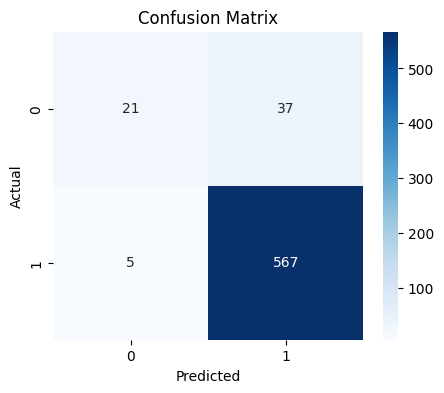

In [16]:
# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.36      0.50        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.87      0.68      0.73       630
weighted avg       0.93      0.93      0.92       630



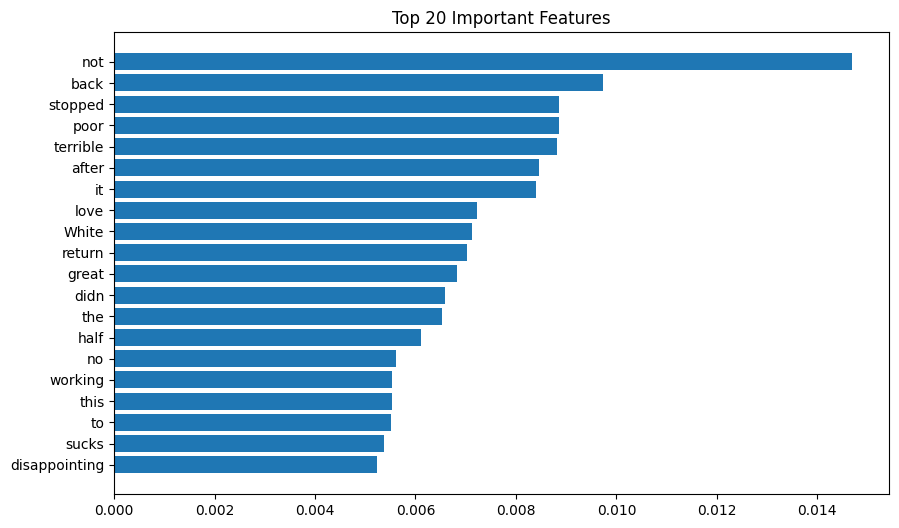

In [18]:
# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model

importances = model.feature_importances_

# Get top 20 features
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), df_final.columns[indices])
plt.title("Top 20 Important Features")
plt.show()

In [19]:
# TODO: Make predictions on new data
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

# Prediction Function

def predict_sentiment(review_text):
    # Transform review using trained vectorizer
    review_vector = cv.transform([review_text]).toarray()

    # Convert to DataFrame
    review_df = pd.DataFrame(review_vector, columns=cv.get_feature_names_out())

    # Add missing columns (variation dummies)
    for col in variation_dummies.columns:
        review_df[col] = 0

    # Reorder columns to match training data
    review_df = review_df.reindex(columns=df_final.columns, fill_value=0)

    # Predict
    prediction = model.predict(review_df)[0]

    return "Positive" if prediction == 1 else "Negative"

In [20]:
# Example usage of your prediction function:
# new_review = "I love my Alexa device! It's so helpful."
# predicted_sentiment = predict_sentiment(new_review)
# print(f"The sentiment of the new review is: {predicted_sentiment}")

# Example Prediction

new_review = "I love my Alexa device! It's so helpful."
predicted_sentiment = predict_sentiment(new_review)

print(f"The sentiment of the new review is: {predicted_sentiment}")

The sentiment of the new review is: Positive


In [78]:
# Task 1: Import Libraries and Dataset

# Hint: You need to import libraries like pandas, numpy, matplotlib, seaborn, etc.
# Don't forget to mount Google Drive and load the CSV file using pandas.
# Use `pd.read_csv()` to load the data into a pandas DataFrame.

# TODO: Import necessary libraries
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [79]:
!kaggle datasets download -d sid321axn/amazon-alexa-reviews

Dataset URL: https://www.kaggle.com/datasets/sid321axn/amazon-alexa-reviews
License(s): other
amazon-alexa-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [80]:
!unzip amazon-alexa-reviews.zip

Archive:  amazon-alexa-reviews.zip
replace amazon_alexa.tsv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: amazon_alexa.tsv        


In [81]:
# TODO: Load the dataset into a DataFrame and preview the first few rows

# Load dataset
df = pd.read_csv('amazon_alexa.tsv', sep='\t')

# Preview data
print(df.head())

   rating       date         variation  \
0       5  31-Jul-18  Charcoal Fabric    
1       5  31-Jul-18  Charcoal Fabric    
2       4  31-Jul-18    Walnut Finish    
3       5  31-Jul-18  Charcoal Fabric    
4       5  31-Jul-18  Charcoal Fabric    

                                    verified_reviews  feedback  
0                                      Love my Echo!         1  
1                                          Loved it!         1  
2  Sometimes while playing a game, you can answer...         1  
3  I have had a lot of fun with this thing. My 4 ...         1  
4                                              Music         1  


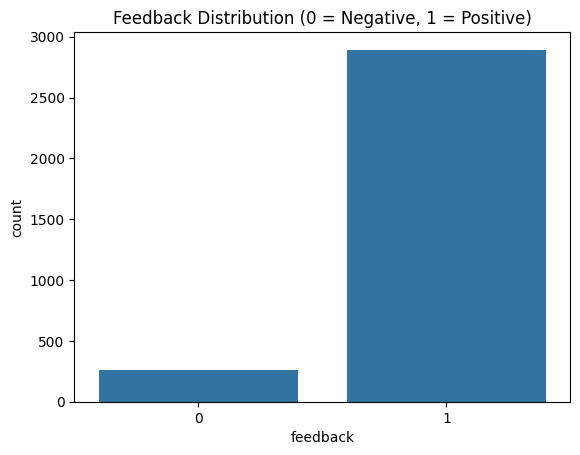

In [82]:
# Hint: Use `sns.countplot()` to visualize the feedback distribution and a bar plot to compare variations and feedback.
# Drop the columns 'date' and 'rating' as they are not relevant for the analysis.

# TODO: Visualize the distribution of feedback (positive/negative)

sns.countplot(x='feedback', data=df)
plt.title("Feedback Distribution (0 = Negative, 1 = Positive)")
plt.show()

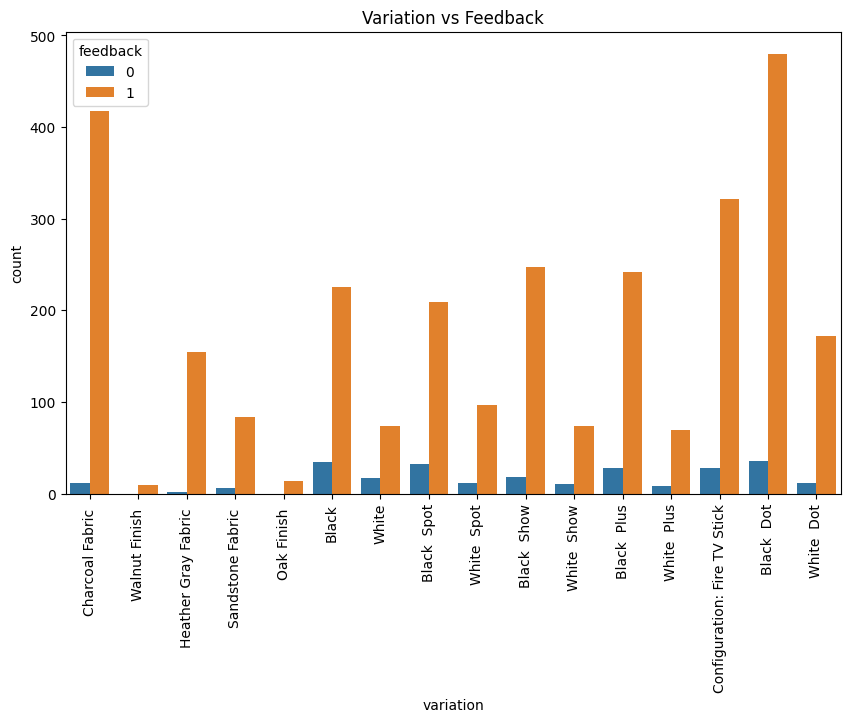

In [83]:
# TODO: Visualize the relationship between product variation and feedback

# Visualize variation vs feedback
plt.figure(figsize=(10,6))
sns.countplot(x='variation', hue='feedback', data=df)
plt.xticks(rotation=90)
plt.title("Variation vs Feedback")
plt.show()

In [84]:
# TODO: Drop irrelevant columns ('date', 'rating')

df.drop(['date', 'rating'], axis=1, inplace=True)
df.head()

,variation,verified_reviews,feedback
0,Charcoal Fabric,Love my Echo!,1
1,Charcoal Fabric,Loved it!,1
2,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,Charcoal Fabric,Music,1


In [85]:
# Task 3: One-Hot Encoding
# Hint: Use `pd.get_dummies()` to create one-hot encoded columns for 'variation'.
# Then, concatenate these encoded columns back to the original DataFrame and drop the 'variation' column.

# TODO: Perform one-hot encoding on the 'variation' column
variation_dummies = pd.get_dummies(df['variation'], drop_first=True)

# Concatenate and drop original column
df = pd.concat([df, variation_dummies], axis=1)
df.drop('variation', axis=1, inplace=True)

df.head()

,verified_reviews,feedback,Black Dot,Black Plus,Black Show,Black Spot,Charcoal Fabric,Configuration: Fire TV Stick,Heather Gray Fabric,Oak Finish,Sandstone Fabric,Walnut Finish,White,White Dot,White Plus,White Show,White Spot
0,Love my Echo!,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,Loved it!,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
2,"Sometimes while playing a game, you can answer...",1,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
3,I have had a lot of fun with this thing. My 4 ...,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
4,Music,1,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


In [88]:
df['verified_reviews'] = df['verified_reviews'].fillna('')

X_text = cv.fit_transform(df['verified_reviews'])

In [89]:
print(df['verified_reviews'].isna().sum())

0


In [90]:
df['verified_reviews'] = df['verified_reviews'].fillna('')

In [91]:
# Task 4: Text Tokenization
# Hint: Use `CountVectorizer` to tokenize the text data and convert it into numerical representation.
# After transforming the text, drop the 'verified_reviews' column and concatenate the numerical data with the rest of the DataFrame.

# TODO: Tokenize the 'verified_reviews' column using CountVectorizer
# Handle missing values (IMPORTANT FIX)

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X_text = cv.fit_transform(df['verified_reviews'])

# Convert sparse matrix to DataFrame
X_text_df = pd.DataFrame(X_text.toarray(), columns=cv.get_feature_names_out())

# Drop original text column
df.drop('verified_reviews', axis=1, inplace=True)

# Combine all features
df = pd.concat([df, X_text_df], axis=1)

df.head()

,feedback,Black Dot,Black Plus,Black Show,Black Spot,Charcoal Fabric,Configuration: Fire TV Stick,Heather Gray Fabric,Oak Finish,Sandstone Fabric,...,youtube,yr,yrs,yup,zero,zigbee,zonked,zzzz,zzzzzzz,útil
0,1,False,False,False,False,True,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,1,False,False,False,False,True,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,1,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,1,False,False,False,False,True,False,False,False,False,...,0,1,0,0,0,0,0,0,0,0
4,1,False,False,False,False,True,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [92]:
# Task 5: Train-Test Split
# Hint: Use `train_test_split()` to split the data into training and testing sets.
# You need to specify `test_size=0.2` to reserve 20% of the data for testing.

# TODO: Split the data into training and testing sets
X = df.drop('feedback', axis=1)
y = df['feedback']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [93]:
# Task 6: Train Random Forest Model
# Hint: Initialize a `RandomForestClassifier` with 100 estimators.
# Use the `fit()` method to train the model on the training data.

# TODO: Define and train a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

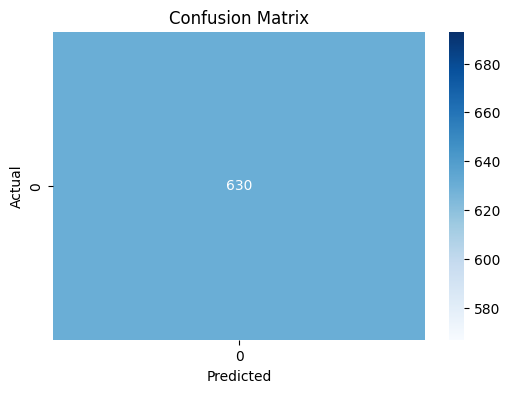

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       572
           1       0.00      0.00      0.00         0

   micro avg       0.94      0.99      0.96       572
   macro avg       0.47      0.49      0.48       572
weighted avg       0.94      0.99      0.96       572
 samples avg       0.90      0.90      0.90       572



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [106]:
# Task 7: Evaluation
# Hint: Use the `predict()` method to generate predictions for the test data.
# Use `confusion_matrix()` to create the confusion matrix and visualize it using a heatmap.
# Print out a `classification_report()` to evaluate the model's precision, recall, and F1 score.

# TODO: Generate predictions and evaluate the model's performance using a confusion matrix and classification report

# Predictions
y_pred = rf.predict(X_test)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

In [107]:
# Task 8: Analyze Model Performance
# Hint: Use the `score()` method to calculate accuracy for both training and test sets.
# Compare the results and discuss if the model is overfitting or underfitting.

# TODO: Compare training and testing accuracy and discuss model performance

train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9964285714285714
Testing Accuracy: 0.9333333333333333
